# Flight mechanincs 2 : Phase 3
##### ✅Groupe name = ✈️ <br>
##### ✅Groupe members = <b> Seyed Mani Seyed SalehiZadeh, Sarah Barati, Arshia Alizadeh </b>


---

<image src="./resources/Project_phase3.png"/>

----

### Setting up the workspace and importing the dependencies

In [99]:
import numpy as np 
import matplotlib.pyplot as plt
import scipy as sp

# For commenting and documnetaion perpouses
from typing import Callable
import seaborn as sns

Since withint the given equations there are 4 state variables and we only have 3 equations we have to bring in the auxilary equatiosn which would relate the body rate to the time rate of change of Euler angles:

$$\begin{pmatrix} p \\ q \\ r \end{pmatrix} = \begin{pmatrix} 1 & 0 & -\sin\theta \\ 0 & \cos\phi & \cos\theta \sin\phi \\ 0 & -\sin\phi & \cos\theta \cos\phi \end{pmatrix} \begin{pmatrix} \dot{\phi} \\ \dot{\theta} \\ \dot{\psi} \end{pmatrix}$$

Let's assume that within our specific flight condition the $\theta$ and $\dot{\psi}$ are small enough so that the below equation would stay valid 

$$p \approx \dot{\phi}$$

Under these conditions we can setup the state space model of our system:

**Our state variables will become:**

$$\vec{x}_{\text{lat}} = \begin{pmatrix} \beta \\ p \\ r \\ \phi \end{pmatrix}$$

**Our input vector will be:**

$$\vec{u} = \begin{pmatrix} \delta_A \\ \delta_R \end{pmatrix}$$

**The disturbance vector will be:**

$$\vec{d} = \begin{pmatrix} F_T \\ L_T \\ (N_T + \Delta D) \\ 0 \end{pmatrix}$$

In [78]:
# == Inputing the distrubance values ==
F_T = -0.01
L_T = -0.005
N_T = -0.015
delta_D = -0.015

# == Setting up the satate space model ==
A = np.array([
    [-8.6,     0,   0,   -0.25],
    [-2,    -6.5,   0,       0],
    [1,     -0.2,-0.6,       0],
    [0,        1,   0,       0]
])

B = np.array([
    [0, 0.04],
    [4, 0.08],
    [0.05,-1],
    [0,    0]
])

d = np.reshape(np.array([F_T, L_T, (N_T+delta_D) , 0]), (A.shape[0], 1))

-----

## Setting up the solver 
In this section we write the code that would be used to solve the state space differnetial equations. 
This code will be used only to validate the discretization process of our matrices. Within the python program we will only work with **discrete** model of the system. This would help us later when we would try to desgin the LQR controller since we can do these two following things 
1) The **Algabric Ricatti Equation** can be used inorder to find the the suboptimal control signal $K_{\infty}$ 
2) We would have a lower computiaional load when we want to solve for the **Optimal Kalman Gain** because a only simple difference equations should be solved rather than differential equtions

In [79]:
# == Continoues time solver ==
def solverC(A:np.ndarray, 
            B:np.ndarray, 
            D:Callable[[np.ndarray, float], np.ndarray], 
            u:Callable[[np.ndarray, float], np.ndarray], 
            t_final: float, 
            t_start: float = 0, 
            t_step: float = 0.01, 
            X0: np.ndarray = np.zeros([A.shape[0]])):
    """
    A simple Linear state space solver model that can be used to calcualte the response of the system
    Note that the D and u are functions of time and state while the A, B are time-invarient for the 
    continoues time models
    """

    # Setting up the equation   
    f = lambda X, t: np.reshape(A @ X + B @ u(X, t) + D(X, t), (len(X)))

    # Setting up the time steps
    t = np.arange(t_start, t_final, t_step)

    # Integrating the f(x, t) to find the X at different time points 
    X = sp.integrate.odeint(f, X0, t)

    return X, t


----

## Solving the zero input problem
Inorder to find what would be the repsonse of the aircraft without any actions taken by the pilot we have to set the u(x,t) = 0 and see the response of the system

In [80]:
# Zero input solution
u_zero = lambda x, t: np.zeros((B.shape[1]))

# Disturbances as a callable 
D = lambda x, t : np.transpose(d)

# Time intervals
t_start = 0
t_step = 0.01
t_final = 100

# Inital conditions ( As a column vector )
X0 = np.zeros([A.shape[0]])

# == Solving the equation == 
x_zero_input, time_interval = solverC(A, B, D, u_zero, t_final, t_start, t_step, X0)

Text(0, 0.5, 'Different angles')

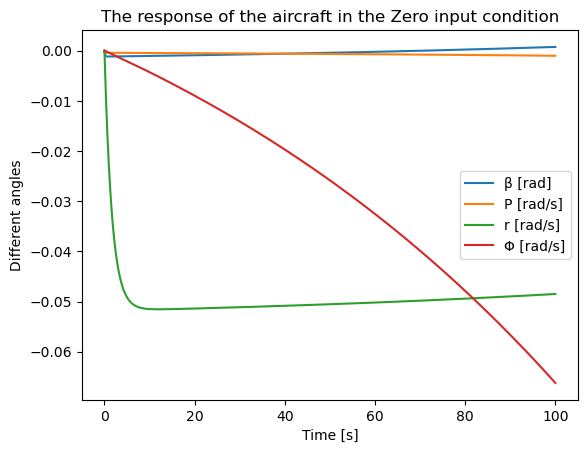

In [81]:
# == Plottong the response of the system == 
plt.plot(time_interval, x_zero_input[:,0], )
plt.plot(time_interval, x_zero_input[:,1])
plt.plot(time_interval, x_zero_input[:,2])
plt.plot(time_interval, x_zero_input[:,3])
plt.title("The response of the aircraft in the Zero input condition")
plt.xlabel("Time [s]")
plt.legend(["β [rad]", "P [rad/s]", "r [rad/s]", "Φ [rad/s]"])
plt.ylabel("Different angles")

We have to find the Largest $\beta$ angle which the airplane will reach in this case we can simply find the max value of the column coresponding to the beta

In [82]:
# Finding the largest Beta (Negative or Positive doesn't matter we only care about the magnitude)
beta_max = np.max(x_zero_input[:,0]) if np.abs(np.max(x_zero_input[:,0])) > np.abs(np.min(x_zero_input[:,0])) else np.min(x_zero_input[:,0])

# Printing out the results
print(" +============================================================+")
print(f"|| Maximum value of side slip angle: {beta_max * 180/3.14} deg || ")
print(" +============================================================+")

 +============================================================+
|| Maximum value of side slip angle: -0.06615785802087043 deg || 
 +============================================================+


------

## Required deflection of aileron and rudder
$\mathbf{\text{If there is no net torque acting about the x-axis of the airplane the airplane won't experience rolling acceleration that is :}} \\$
$$
 \dot{p} = 0 
$$

$\mathbf{\text{And assuming a zero inital condition we can also conculde that:}} \\$


$$
 p = \beta = \phi = 0
$$

$\mathbf{\text{And subsequently we conclude that:}} \\$

$$
\dot{\phi} = 0 
$$

$\mathbf{\text{So we can solve the problem analyticaly (By hand) to obtain the following values for 
the aileron and rudder deflection:
}} \\$

$\mathbf{\text{Original Equations:}} \\$

$$\begin{aligned}\\
\dot{\beta} &= -8.6\beta - 0.25\phi + 0.04\delta_R + F_T \\
\dot{p} &= -2.0\beta - 6.5p + 4.0\delta_A + 0.08\delta_R + L_T \\
\end{aligned}$$

$\mathbf{\text{Applying Conditions:}} \\$
$$\begin{aligned}

0 &= -8.6(0) - 0.25(0) + 0.04\delta_R + F_T \quad \text{(Eq. 1)} \\
0 &= -2.0(0) - 6.5(0) + 4.0\delta_A + 0.08\delta_R + L_T \quad \text{(Eq. 2)} \\
\end{aligned}$$

$\mathbf{\text{Simplified System:}} \\$
$$\begin{aligned}
0 &= 0.04\delta_R + F_T \quad \text{(Eq. 1)} \\
0 &= 4.0\delta_A + 0.08\delta_R + L_T \quad \text{(Eq. 2)}
\end{aligned}$$

$\mathbf{\text{ Solving for } \delta_R \text{ from Eq. 1:}} \\$

$$\begin{aligned}
0.04\delta_R &= -F_T \\
\delta_R &= \frac{-F_T}{0.04} \\
\mathbf{\delta_R} &= \mathbf{-25 F_T}
\end{aligned}$$

$\mathbf{\text{ Solving for } \delta_A \text{ by substituting } \delta_R \text{ into Eq. 2:}} \\$

$$\begin{aligned}
0 &= 4.0\delta_A + 0.08\left(-25 F_T\right) + L_T \\
0 &= 4.0\delta_A - 2 F_T + L_T \\
4.0\delta_A &= 2 F_T - L_T \\
\delta_A &= \frac{2 F_T - L_T}{4.0} \\
\mathbf{\delta_A} &= \mathbf{0.5 F_T - 0.25 L_T}
\end{aligned}$$

$\mathbf{\text{ The results are as below:}} \\$

$$
\delta_A = -0.00375 rad \approx -2.1497^{\circ}
$$
$$
\delta_R  = 0.25 rad \approx 14.33^{\circ}
$$ 

**Here we can validate the obtained results.**

In [83]:
# Zero input solution
u1 = lambda x, t: np.array([-0.00375, 0.25])

# Disturbances as a callable 
D = lambda x, t : np.transpose(d)

# Time intervals
t_start = 0
t_step = 0.01
t_final = 100

# Inital conditions ( As a column vector )
X0 = np.zeros([A.shape[0]])

# == Solving the equation == 
x_solution1, time_interval = solverC(A, B, D, u1, t_final, t_start, t_step, X0)

Text(0, 0.5, 'Different angles')

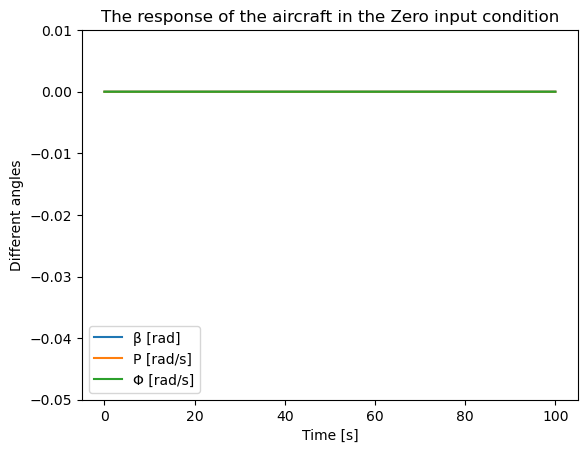

In [84]:
# == Plottong the response of the system == 
plt.plot(time_interval, x_solution1[:,0])
plt.plot(time_interval, x_solution1[:,1])
plt.plot(time_interval, x_solution1[:,3])
plt.title("The response of the aircraft in the Zero input condition")
plt.xlabel("Time [s]")
plt.ylim(-0.05, 0.01)
plt.legend(["β [rad]", "P [rad/s]", "Φ [rad/s]"])
plt.ylabel("Different angles")

----

## Required deflection for the continued crusing condition
Inorder to continue the crusing we have to find the values for $\delta_A$ and $\delta_R$ such that:

$$
\dot{p} = \dot{r} = \dot{\phi} = 0
$$

In order to find the solution to this problem we will make one extra assumption(Although not neccessary but neither limiting) that
$$
\dot{\beta} = 0 
$$
and 
$$
\phi = 0
$$

If we substitude the above assumptions to the orignal equations we will get to this system of linear equations:

$$\text{Applying the steady-state conditions } \dot{\beta}=0, \dot{p}=0, \dot{r}=0, p=0, r=0, \phi=0 \text{ to the equations:}$$
$$\begin{aligned}
0 &= -8.6\beta + 0.04\delta_R + F_T \\
0 &= -2.0\beta + 4.0\delta_A + 0.08\delta_R + L_T \\
0 &= \beta + 0.05\delta_A - \delta_R + (N_T + \Delta D)
\end{aligned}$$

$$\text{Rearranging into the matrix form } \mathbf{M} \mathbf{x} = \mathbf{b} \text{ where } \mathbf{x} = \begin{pmatrix} \beta \\ \delta_R \\ \delta_A \end{pmatrix} \text{ and } \mathbf{b} \text{ contains the disturbance terms:}$$
$$\begin{pmatrix} -8.6 & 0.04 & 0 \\ -2.0 & 0.08 & 4.0 \\ 1 & -1 & 0.05 \end{pmatrix} \begin{pmatrix} \beta \\ \delta_R \\ \delta_A \end{pmatrix} = \begin{pmatrix} -F_T \\ -L_T \\ -(N_T + \Delta D) \end{pmatrix}$$

$$\text{The symbolic solution for the unknown vector is:}$$
$$\begin{pmatrix} \beta \\ \delta_R \\ \delta_A \end{pmatrix} = \begin{pmatrix} -8.6 & 0.04 & 0 \\ -2.0 & 0.08 & 4.0 \\ 1 & -1 & 0.05 \end{pmatrix}^{-1} \begin{pmatrix} -F_T \\ -L_T \\ -(N_T + \Delta D) \end{pmatrix}$$

$$\text{Using the code below we have found that:}$$
$$\begin{pmatrix} \beta \\ \delta_R \\ \delta_A \end{pmatrix} = \begin{pmatrix} -0.00101883 \\ -0.03095085 \\ 0.0013596 \end{pmatrix}$$


In [85]:
# == Solution of the matrix using the matrix inversion ==
# Coefficent matrix
coeff = np.array([
    [-8.6, 0.04, 0],
    [-2, 0.08, 4],
    [1, -1 ,0.05]
])

# The a known matrix
y = np.array([
    [-F_T],
    [-L_T],
    [-N_T-delta_D]
])

# The solution matrix
ans = np.linalg.inv(coeff) @ y

Now we can just solve the equation to insure the obtained results are correct.

In [86]:
# Input vector
u2 = lambda x, t: np.array([ans[2,0], ans[1,0]])

# Disturbances as a callable 
D = lambda x, t : np.transpose(d)

# Time intervals
t_start = 0
t_step = 0.001
t_final = 400

# Inital conditions ( As a column vector )
X0 = np.zeros([A.shape[0]])
X0[0] = ans[0,0]

# == Solving the equation == 
x2, time_interval = solverC(A, B, D, u2, t_final, t_start, t_step, X0)

Text(0, 0.5, 'Different angles')

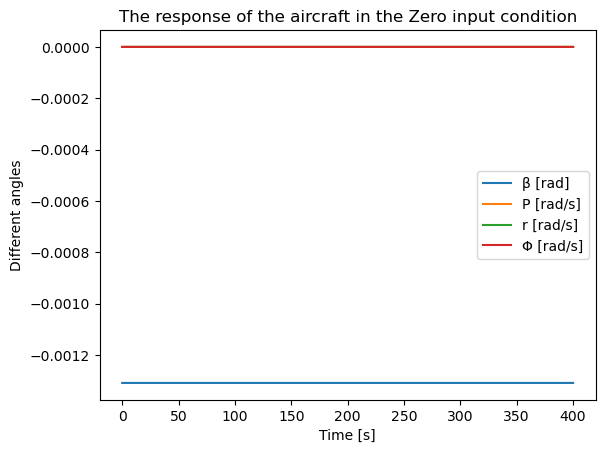

In [87]:
# == Plottong the response of the system == 
plt.plot(time_interval, x2[:,0], )
plt.plot(time_interval, x2[:,1])
plt.plot(time_interval, x2[:,2])
plt.plot(time_interval, x2[:,3])
plt.title("The response of the aircraft in the Zero input condition")
plt.xlabel("Time [s]")
plt.legend(["β [rad]", "P [rad/s]", "r [rad/s]", "Φ [rad/s]"])
plt.ylabel("Different angles")

**NOTE: That the above solution is obtained with the assumption that we had the mentioned $\Beta$ prior to the engine failure. So the transient response of the system may make the system should also be considered for this perpouse however a contorller has to be desgined which is done in the subsequent sections.**

----

## Sensetivity analysis 
We will have to change the different values related to the engine failure to obtain a valid analysis of how they will effect the maximum side slip angle $\beta_{max}$ .

The values which we have changed were:
- $L_{T}$
- $F_{T}$
- $N_{T}$
- $\Delta D$

In [96]:
# == Making a mesh of the possible combinations ==
L_T_range = L_T * np.array([0.8, 1, 1.2]) 
N_T_range = N_T * np.array([0.8, 1, 1.2]) 
delta_D_range = delta_D * np.array([0.8, 1, 1.2])

F_T_range =  np.array([-0.01, -0.015, -0.02, -0.03]) 

# Create a mesh map of all combinations
mesh = np.meshgrid(L_T_range, N_T_range, delta_D_range, F_T_range)

# Stack and reshape to get array of combinations
combinations = np.stack(mesh, axis=-1).reshape(-1, 4)

# == Solving for each one of the combinations and storing the maximum beta angle ==
beta_maxs = []

for index in range(0, len(combinations)):
    # Disturbances as a callable 
    D = lambda x, t : np.transpose(combinations[index])

    # Solving the equation
    x_sol, _ = solverC(A, B, D, u2, t_final, t_start, t_step, X0)

    # Finding the maximum beta angle
    beta_maxs.append(np.max(x_sol[:,0]))

beta_maxs = np.array(beta_maxs)

C:\Users\Mani\AppData\Local\Temp\ipykernel_23412\3686617828.py:54: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



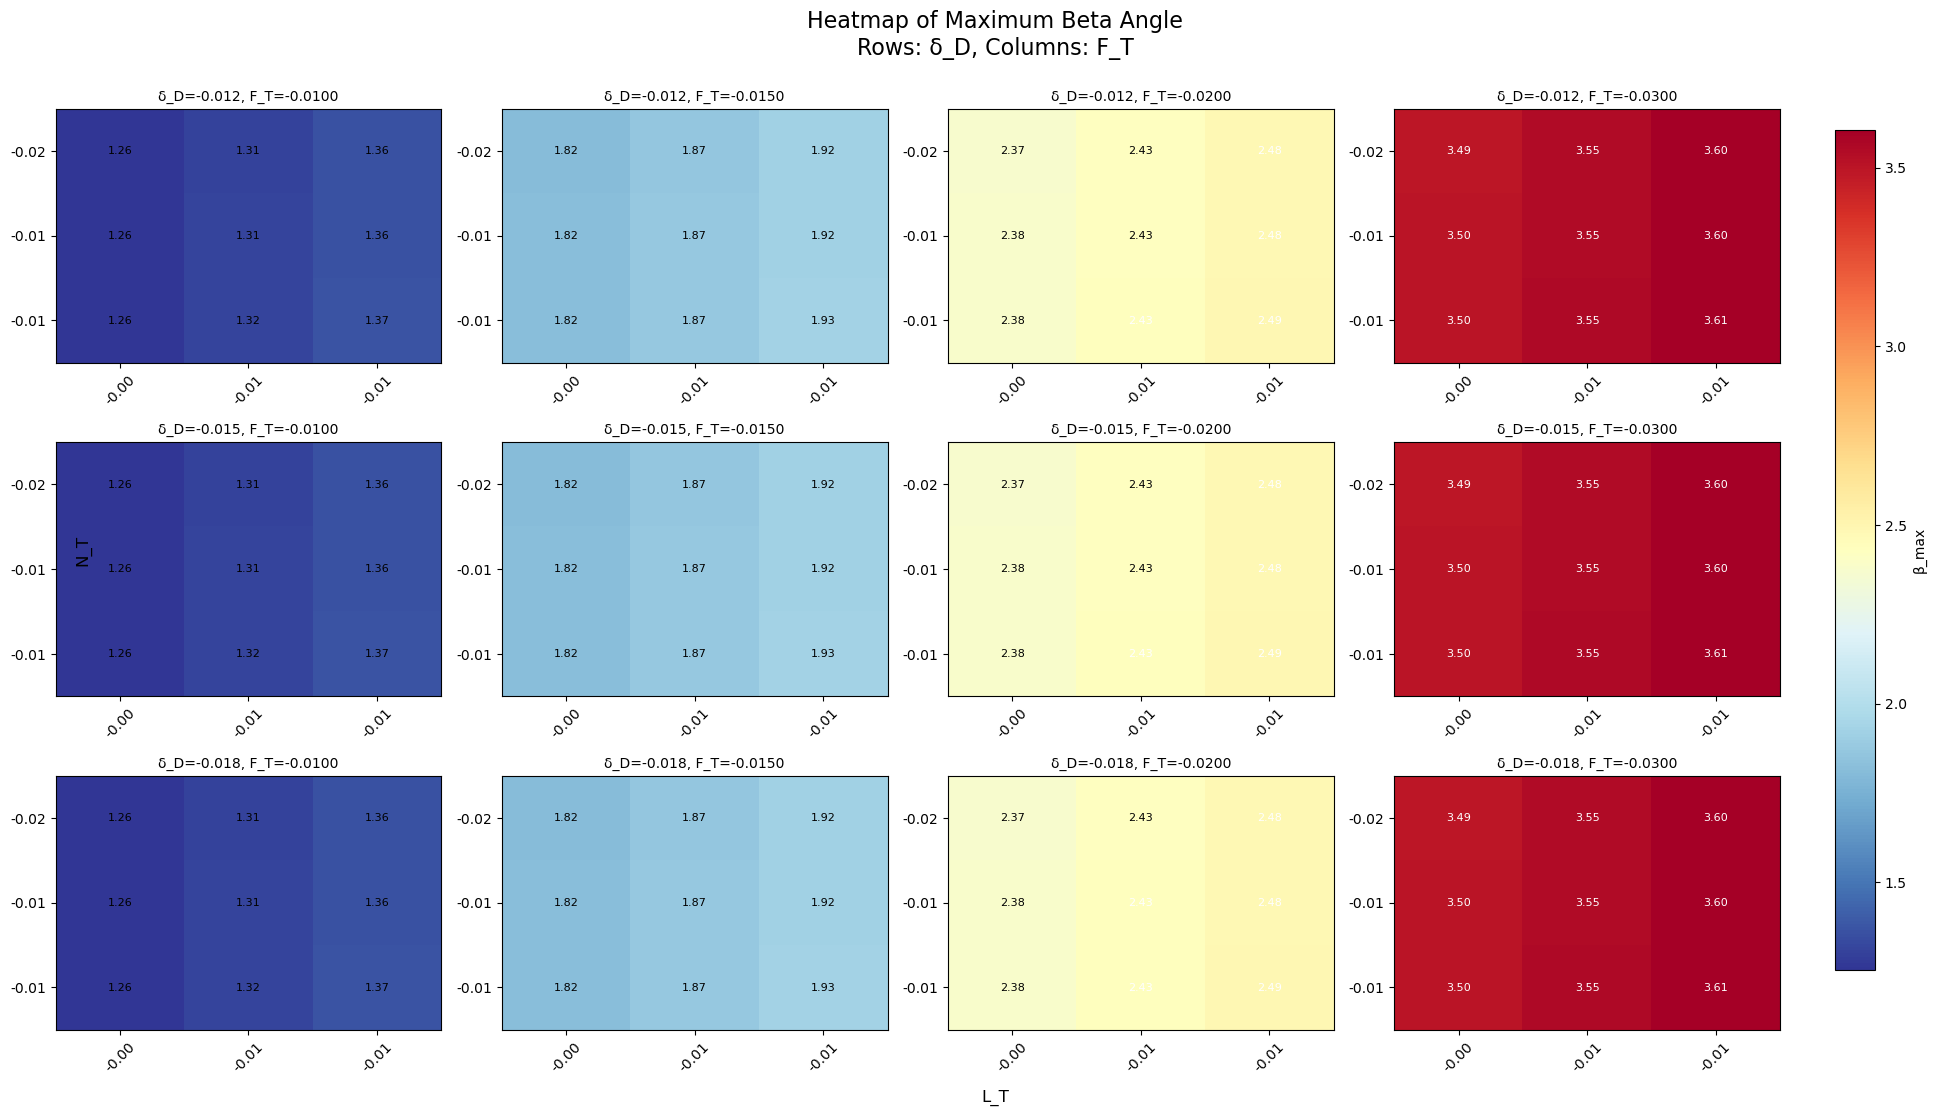

In [103]:
# Reshape data for heatmaps
beta_maxs_grid = beta_maxs.reshape(len(L_T_range), 
                                    len(N_T_range), 
                                    len(delta_D_range), 
                                    len(F_T_range))

# Create a 3×4 grid of heatmaps
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle('Heatmap of Maximum Beta Angle\nRows: δ_D, Columns: F_T', 
             fontsize=16, y=0.95)

# Find global min/max for consistent color scale
vmin, vmax = beta_maxs.min(), beta_maxs.max()

for d_idx, d_val in enumerate(delta_D_range):
    for f_idx, f_val in enumerate(F_T_range):
        ax = axes[d_idx, f_idx]
        
        # Get data for this combination
        data = beta_maxs_grid[:, :, d_idx, f_idx].T
        
        # Create heatmap
        im = ax.imshow(data, 
                      cmap='RdYlBu_r', 
                      vmin=vmin, vmax=vmax,
                      aspect='auto',
                      origin='lower')
        
        # Set ticks and labels
        ax.set_xticks(range(len(L_T_range)))
        ax.set_yticks(range(len(N_T_range)))
        ax.set_xticklabels([f'{x:.2f}' for x in L_T_range], rotation=45)
        ax.set_yticklabels([f'{y:.2f}' for y in N_T_range])
        
        # Title
        ax.set_title(f'δ_D={d_val:.3f}, F_T={f_val:.4f}', fontsize=10)
        
        # Add value annotations
        for i in range(len(N_T_range)):
            for j in range(len(L_T_range)):
                ax.text(j, i, f'{data[i, j]:.2f}',
                       ha='center', va='center',
                       color='white' if data[i, j] > (vmin+vmax)/2 else 'black',
                       fontsize=8)

# Add colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='β_max')

# Labels
fig.text(0.5, 0.04, 'L_T', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'N_T', va='center', rotation='vertical', fontsize=12)

plt.tight_layout(rect=[0, 0.05, 0.9, 0.95])
plt.show()

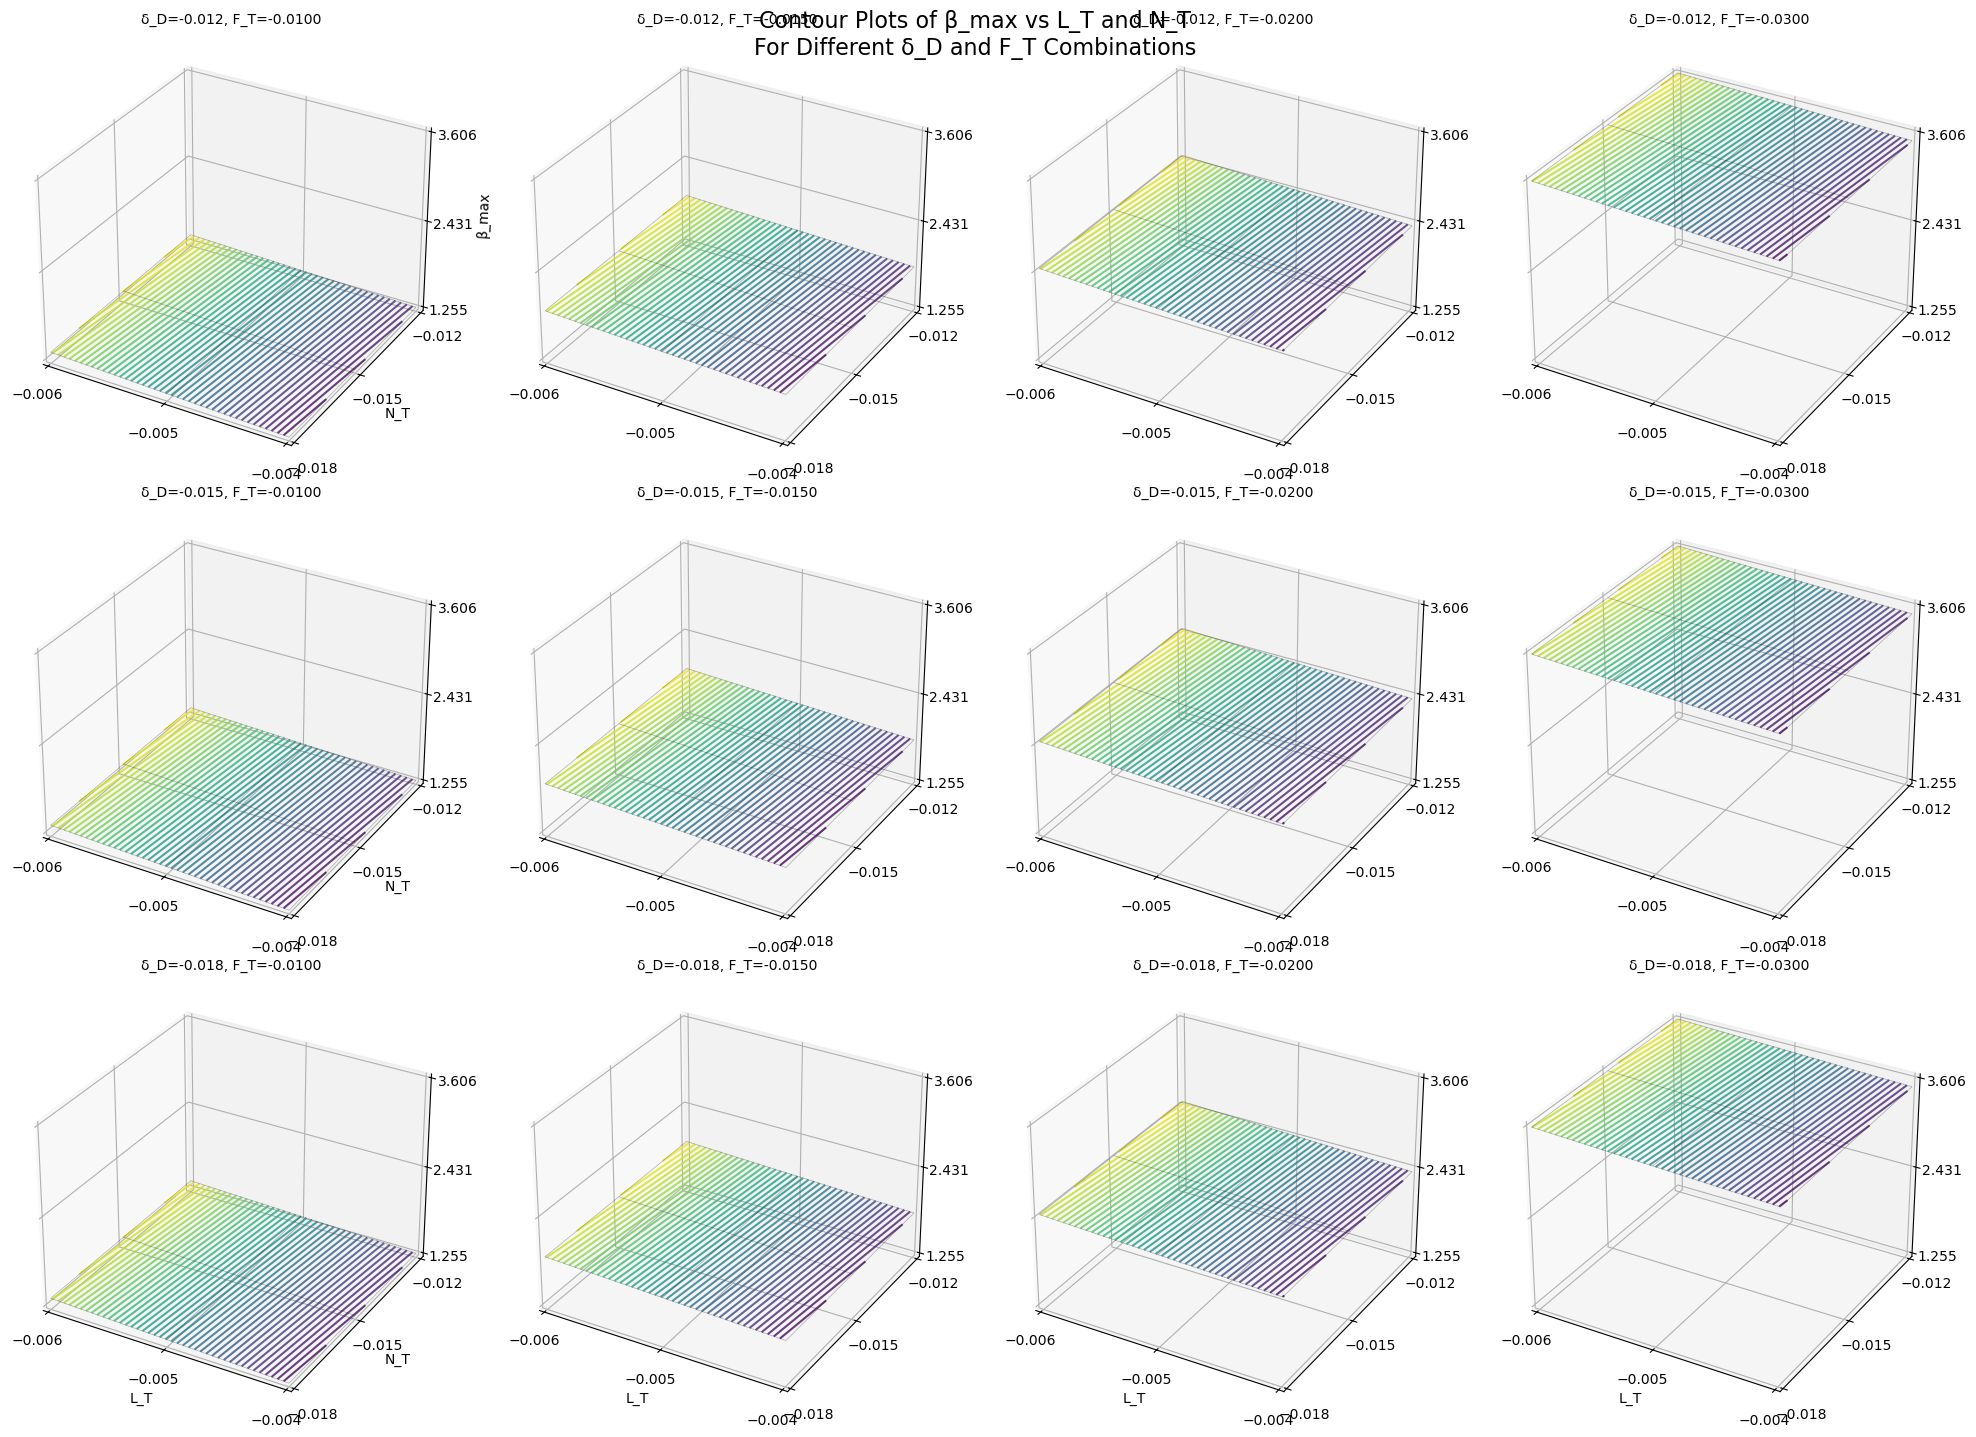

In [110]:
# Create contour plot matrix
fig, axes = plt.subplots(3, 4, figsize=(20, 15), subplot_kw={'projection': '3d'})

for d_idx, d_val in enumerate(delta_D_range):
    for f_idx, f_val in enumerate(F_T_range):
        ax = axes[d_idx, f_idx]
        
        # Get data for this combination
        X, Y = np.meshgrid(L_T_range, N_T_range)
        Z = beta_maxs_grid[:, :, d_idx, f_idx].T
        
        # Create contour plot on surface
        ax.contour3D(X, Y, Z, 50, cmap='viridis', alpha=0.8)
        
        # Wireframe for structure
        ax.plot_wireframe(X, Y, Z, color='black', alpha=0.3, linewidth=0.5)
        
        # Set consistent limits
        ax.set_xlim(L_T_range.min(), L_T_range.max())
        ax.set_ylim(N_T_range.min(), N_T_range.max())
        ax.set_zlim(vmin, vmax)
        
        ax.set_title(f'δ_D={d_val:.3f}, F_T={f_val:.4f}', fontsize=10)
        
        # Only label outer plots
        if f_idx == 0:
            ax.set_ylabel('N_T', fontsize=10)
        if d_idx == 2:
            ax.set_xlabel('L_T', fontsize=10)
        if d_idx == 0 and f_idx == 0:
            ax.set_zlabel('β_max', fontsize=10)

        # Show min, middle, and max values
        ax.set_xticks([L_T_range.min(), (L_T_range.min()+L_T_range.max())/2, L_T_range.max()])
        ax.set_yticks([N_T_range.min(), (N_T_range.min()+N_T_range.max())/2, N_T_range.max()])
        ax.set_zticks([vmin, (vmin+vmax)/2, vmax])


fig.suptitle('Contour Plots of β_max vs L_T and N_T\nFor Different δ_D and F_T Combinations', 
             fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

---